# Linear Regression example

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

### The return of the Ice Cream Shop...

In [2]:
np.random.seed(42)
n = 80

temperature = np.linspace(55, 100, n) + np.random.normal(0, 1.2, n)
sales = 8 * temperature - 210 + np.random.normal(0, 18, n)

# data sets generated using np.linspace to create evenly spaced temperature values
# both use addition of np.random.normal noise 
# this is a common technique for generating realistic-looking practice data

data = {
    'temperature_f': np.round(temperature, 1),
    'sales_dollars': np.round(sales, 2)
}

df_icecream = pd.DataFrame(data)

df_icecream

,temperature_f,sales_dollars
0,55.6,230.81
1,55.4,239.66
2,56.9,271.93
3,58.5,248.96
4,57.0,231.43
...,...,...
75,98.7,566.80
76,98.4,610.75
77,98.5,586.54
78,99.5,564.88


In [3]:
# Step 1: Define features and target
X = df_icecream[['temperature_f']]
y = df_icecream['sales_dollars']

In [4]:
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Step 3: Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# print("Training successful!")

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# Step 4: Make predictions
y_pred = model.predict(X_test)

In [10]:
# Step 5: Evaluate
mae = mean_absolute_error(y_test, y_pred)   # the average gap between predicted and actual scores, in the original units (here degrees/dollars)
r2 = r2_score(y_test, y_pred)               # you want this to be closer to 1

print(f'Mean Absolute Error: {mae:.2f}')
print(f'R² Score:            {r2:.4f}')
print(f'Slope:               {model.coef_[0]:.4f}')
print(f'Intercept:           {model.intercept_:.4f}')

Mean Absolute Error: 13.52
R² Score:            0.9650
Slope:               7.9785
Intercept:           -208.6676


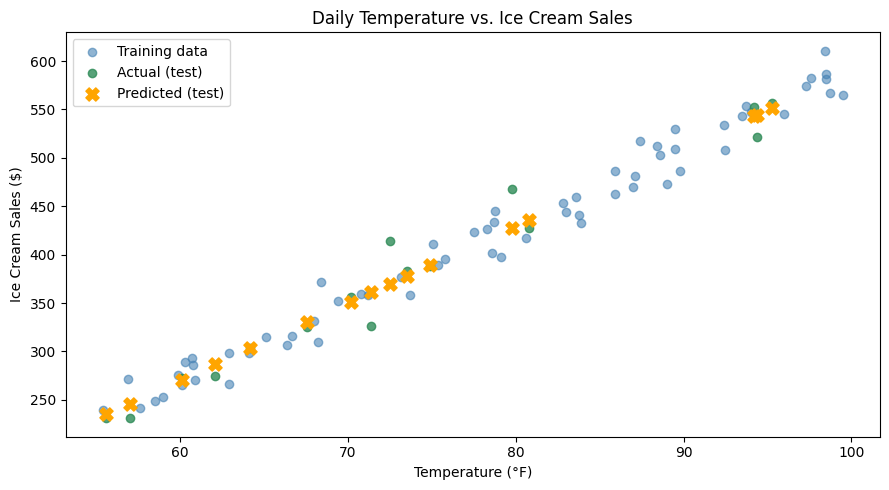

In [11]:
# Step 6: Visualize
plt.figure(figsize=(9, 5))

plt.scatter(X_train, y_train,
            color='steelblue', alpha=0.6, label='Training data', zorder=3)
plt.scatter(X_test, y_test,
            color='seagreen', alpha=0.8, label='Actual (test)', zorder=4)
plt.scatter(X_test, y_pred,
            color='orange', marker='X', s=90,
            label='Predicted (test)', zorder=5)

x_range = pd.DataFrame(
    {'temperature_f': np.linspace(X['temperature_f'].min(),
                                   X['temperature_f'].max(), 200)}
)

# regression line omitted

plt.xlabel('Temperature (°F)')
plt.ylabel('Ice Cream Sales ($)')
plt.title('Daily Temperature vs. Ice Cream Sales')
plt.legend()
plt.tight_layout()
plt.show()

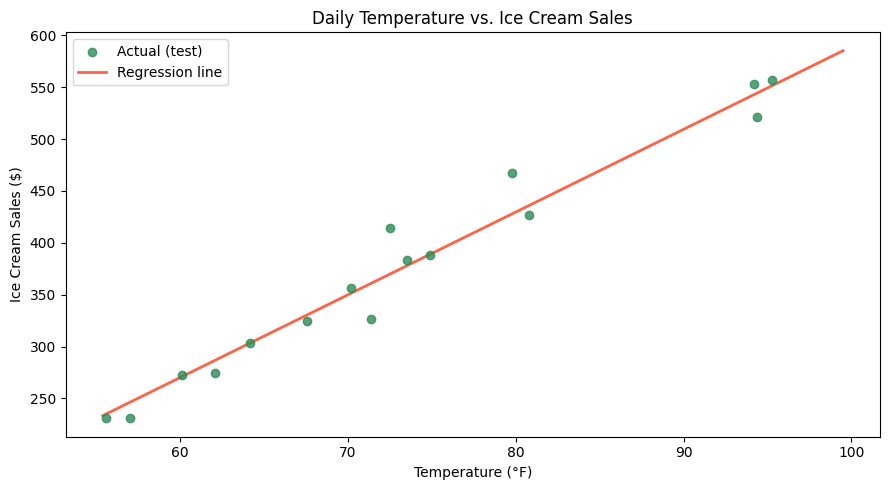

In [12]:
# alternative visualization

plt.figure(figsize=(9, 5))

plt.scatter(X_test, y_test,
            color='seagreen', alpha=0.8, label='Actual (test)', zorder=4)
# plt.scatter(X_test, y_pred,
#             color='orange', marker='X', s=90,
#             label='Predicted (test)', zorder=5)

x_range = pd.DataFrame(
    {'temperature_f': np.linspace(X['temperature_f'].min(),
                                   X['temperature_f'].max(), 200)}
)
plt.plot(x_range, model.predict(x_range),
         color='tomato', linewidth=2, label='Regression line')

plt.xlabel('Temperature (°F)')
plt.ylabel('Ice Cream Sales ($)')
plt.title('Daily Temperature vs. Ice Cream Sales')
plt.legend()
plt.tight_layout()
plt.show()